In [38]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [39]:
print(os.listdir("../data/raw")[0])

yellow_tripdata_2024-08.parquet


In [40]:
os.path.basename("../data/raw/yellow_tripdata_2024-08.parquet")

'yellow_tripdata_2024-08.parquet'

In [41]:
path = os.path.join("../data" , "raw", "yellow_tripdata_2024-08.parquet")
df = pd.read_parquet(path)

In [42]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,1,2024-08-01 00:21:00,2024-08-01 00:36:13,1.0,7.40,1.0,N,138,80,1,28.9,7.75,0.5,7.65,0.00,1.0,45.80,0.0,1.75
1,2,2024-08-01 00:20:01,2024-08-01 00:41:47,1.0,9.91,1.0,N,138,239,1,40.8,6.00,0.5,11.55,6.94,1.0,71.04,2.5,1.75
2,1,2024-08-01 00:17:52,2024-08-01 00:41:45,0.0,13.40,1.0,N,138,88,1,52.0,10.25,0.5,15.00,0.00,1.0,78.75,2.5,1.75
3,1,2024-08-01 00:49:08,2024-08-01 00:55:56,0.0,3.90,1.0,N,209,137,3,17.0,3.50,0.5,0.00,0.00,1.0,22.00,2.5,0.00
4,1,2024-08-01 00:38:52,2024-08-01 00:42:34,1.0,0.40,1.0,N,148,144,2,5.1,3.50,0.5,0.00,0.00,1.0,10.10,2.5,0.00


In [43]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee'],
      dtype='str')

In [44]:
df.isnull().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          258667
trip_distance                 0
RatecodeID               258667
store_and_fwd_flag       258667
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     258667
Airport_fee              258667
dtype: int64

In [45]:
df = df.dropna(subset=[
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_distance",
    "PULocationID",
    "DOLocationID",
    "fare_amount",
    "payment_type"
])

In [46]:
df[df.duplicated(keep=False)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee


In [47]:
df = df.drop_duplicates()

In [48]:
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])


In [49]:
df["trip_duration_min"] = (df["tpep_dropoff_datetime"] - 
                           df["tpep_pickup_datetime"]).dt.total_seconds() / 60

In [50]:
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_day"] = df["tpep_pickup_datetime"].dt.day_name()

In [51]:
df = df[
    (df["trip_duration_min"] > 0) & 
    (df["trip_duration_min"] < 1440)
]

In [52]:
df["trip_speed_kmh"] = df["trip_distance"] / (df["trip_duration_min"] / 60)

In [53]:
df = df[df["trip_speed_kmh"] <= 120]

In [71]:
df["trip_speed_kmh"].max()

np.float64(120.0)

In [55]:
df = df[
    df["trip_distance"] > 0
]

In [56]:
df["fare_per_km"] = df["fare_amount"] / df["trip_distance"]

In [57]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,trip_duration_min,pickup_hour,pickup_day,trip_speed_kmh,fare_per_km
0,1,2024-08-01 00:21:00,2024-08-01 00:36:13,1.0,7.40,1.0,N,138,80,1,...,0.00,1.0,45.80,0.0,1.75,15.216667,0,Thursday,29.178532,3.905405
1,2,2024-08-01 00:20:01,2024-08-01 00:41:47,1.0,9.91,1.0,N,138,239,1,...,6.94,1.0,71.04,2.5,1.75,21.766667,0,Thursday,27.316998,4.117053
2,1,2024-08-01 00:17:52,2024-08-01 00:41:45,0.0,13.40,1.0,N,138,88,1,...,0.00,1.0,78.75,2.5,1.75,23.883333,0,Thursday,33.663643,3.880597
3,1,2024-08-01 00:49:08,2024-08-01 00:55:56,0.0,3.90,1.0,N,209,137,3,...,0.00,1.0,22.00,2.5,0.00,6.800000,0,Thursday,34.411765,4.358974
4,1,2024-08-01 00:38:52,2024-08-01 00:42:34,1.0,0.40,1.0,N,148,144,2,...,0.00,1.0,10.10,2.5,0.00,3.700000,0,Thursday,6.486486,12.750000


In [58]:
df = df[
    [
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "pickup_hour",
        "pickup_day",
        "trip_distance",
        "trip_duration_min",
        "trip_speed_kmh",
        "fare_amount",
        "fare_per_km",
        "passenger_count",
        'extra',
        'mta_tax',
        'tip_amount',
        'tolls_amount', 
        'improvement_surcharge',
        'total_amount', 
        'congestion_surcharge'
    ]
]

In [59]:
df.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,pickup_hour,pickup_day,trip_distance,trip_duration_min,trip_speed_kmh,fare_amount,fare_per_km,passenger_count,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,2024-08-01 00:21:00,2024-08-01 00:36:13,0,Thursday,7.40,15.216667,29.178532,28.9,3.905405,1.0,7.75,0.5,7.65,0.00,1.0,45.80,0.0
1,2024-08-01 00:20:01,2024-08-01 00:41:47,0,Thursday,9.91,21.766667,27.316998,40.8,4.117053,1.0,6.00,0.5,11.55,6.94,1.0,71.04,2.5
2,2024-08-01 00:17:52,2024-08-01 00:41:45,0,Thursday,13.40,23.883333,33.663643,52.0,3.880597,0.0,10.25,0.5,15.00,0.00,1.0,78.75,2.5
3,2024-08-01 00:49:08,2024-08-01 00:55:56,0,Thursday,3.90,6.800000,34.411765,17.0,4.358974,0.0,3.50,0.5,0.00,0.00,1.0,22.00,2.5
4,2024-08-01 00:38:52,2024-08-01 00:42:34,0,Thursday,0.40,3.700000,6.486486,5.1,12.750000,1.0,3.50,0.5,0.00,0.00,1.0,10.10,2.5


In [60]:
# Basic statistics
print(df.describe())


             tpep_pickup_datetime       tpep_dropoff_datetime   pickup_hour  \
count                     2920813                     2920813  2.920813e+06   
mean   2024-08-16 04:37:21.503901  2024-08-16 04:54:51.549006  1.422916e+01   
min           2009-01-01 00:02:52         2009-01-01 20:28:16  0.000000e+00   
25%           2024-08-07 22:51:25         2024-08-07 23:07:28  1.100000e+01   
50%           2024-08-15 21:23:59         2024-08-15 21:39:48  1.500000e+01   
75%           2024-08-23 23:44:58         2024-08-24 00:01:15  1.900000e+01   
max           2024-09-10 12:27:29         2024-09-10 19:45:57  2.300000e+01   
std                           NaN                         NaN  5.808820e+00   

       trip_distance  trip_duration_min  trip_speed_kmh   fare_amount  \
count   2.920813e+06       2.920813e+06    2.920813e+06  2.920813e+06   
mean    3.680151e+00       1.750075e+01    1.150277e+01  1.959030e+01   
min     1.000000e-02       1.666667e-02    6.272214e-04 -1.174100e+03

In [61]:
df.head(2)

,tpep_pickup_datetime,tpep_dropoff_datetime,pickup_hour,pickup_day,trip_distance,trip_duration_min,trip_speed_kmh,fare_amount,fare_per_km,passenger_count,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,2024-08-01 00:21:00,2024-08-01 00:36:13,0,Thursday,7.40,15.216667,29.178532,28.9,3.905405,1.0,7.75,0.5,7.65,0.00,1.0,45.80,0.0
1,2024-08-01 00:20:01,2024-08-01 00:41:47,0,Thursday,9.91,21.766667,27.316998,40.8,4.117053,1.0,6.00,0.5,11.55,6.94,1.0,71.04,2.5


In [62]:
df["pickup_day"].value_counts()

pickup_day
Thursday     514135
Saturday     475922
Friday       469111
Wednesday    401218
Tuesday      391276
Monday       338526
Sunday       330625
Name: count, dtype: int64

In [63]:
print(df["pickup_hour"].value_counts())

pickup_hour
18    207500
17    202047
16    184582
15    180579
19    179942
14    176585
13    167656
20    167293
21    165061
12    159612
22    148160
11    146900
10    133087
9     122819
23    113100
8     107137
0      82217
7      72046
1      56435
6      45370
2      38727
3      25419
5      19919
4      18620
Name: count, dtype: int64


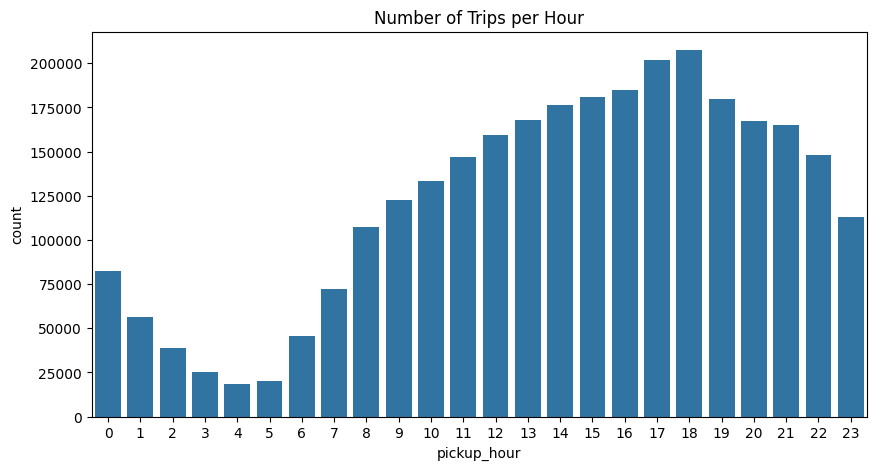

In [64]:
# Trips per hour 
plt.figure(figsize=(10,5))
sns.countplot(x="pickup_hour" , data=df)
plt.title("Number of Trips per Hour")
plt.show()

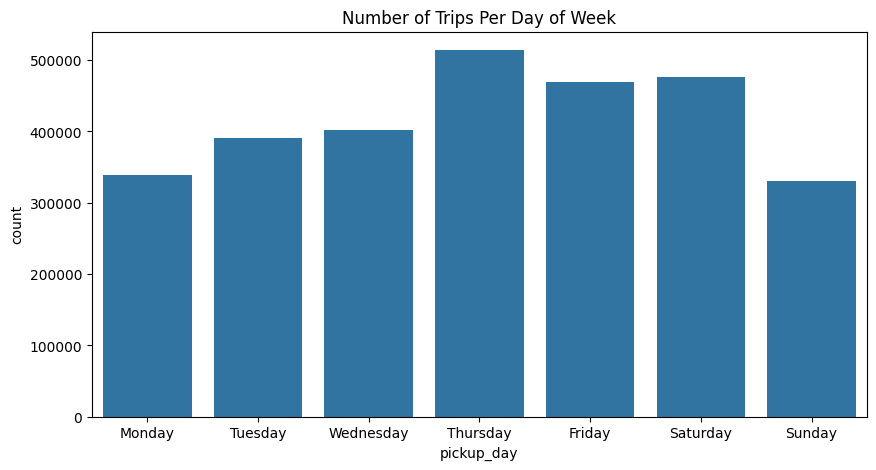

In [65]:
# Trips per day of week
plt.figure(figsize=(10,5))
sns.countplot(x="pickup_day" , data=df , order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Number of Trips Per Day of Week")
plt.show()

In [66]:
df.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,pickup_hour,pickup_day,trip_distance,trip_duration_min,trip_speed_kmh,fare_amount,fare_per_km,passenger_count,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,2024-08-01 00:21:00,2024-08-01 00:36:13,0,Thursday,7.40,15.216667,29.178532,28.9,3.905405,1.0,7.75,0.5,7.65,0.00,1.0,45.80,0.0
1,2024-08-01 00:20:01,2024-08-01 00:41:47,0,Thursday,9.91,21.766667,27.316998,40.8,4.117053,1.0,6.00,0.5,11.55,6.94,1.0,71.04,2.5
2,2024-08-01 00:17:52,2024-08-01 00:41:45,0,Thursday,13.40,23.883333,33.663643,52.0,3.880597,0.0,10.25,0.5,15.00,0.00,1.0,78.75,2.5
3,2024-08-01 00:49:08,2024-08-01 00:55:56,0,Thursday,3.90,6.800000,34.411765,17.0,4.358974,0.0,3.50,0.5,0.00,0.00,1.0,22.00,2.5
4,2024-08-01 00:38:52,2024-08-01 00:42:34,0,Thursday,0.40,3.700000,6.486486,5.1,12.750000,1.0,3.50,0.5,0.00,0.00,1.0,10.10,2.5


In [67]:
duration_by_hour = df.groupby("pickup_hour")["trip_duration_min"].mean()
duration_by_hour

pickup_hour
0     15.666350
1     14.701717
2     13.487983
3     13.531349
4     15.187211
5     16.802997
6     17.107742
7     16.405472
8     16.680041
9     16.952380
10    17.555222
11    18.154941
12    18.596118
13    19.018501
14    19.707234
15    20.079403
16    20.048239
17    18.950861
18    16.936879
19    16.289816
20    15.823180
21    15.674008
22    15.917288
23    16.392200
Name: trip_duration_min, dtype: float64

In [68]:
distance_by_hour = df.groupby("pickup_hour")["trip_distance"].mean()  
distance_by_hour  

pickup_hour
0     4.495914
1     4.140768
2     3.806871
3     3.943014
4     5.202208
5     6.013135
6     4.845118
7     4.087645
8     3.487433
9     3.277141
10    3.349327
11    3.362091
12    3.499814
13    3.563483
14    3.725104
15    3.749646
16    3.758641
17    3.433058
18    3.228024
19    3.394745
20    3.607538
21    3.644247
22    3.931364
23    4.462993
Name: trip_distance, dtype: float64

In [69]:
# High Speed Trips

high_speed_trips = df[df["trip_speed_kmh"] > 110]
high_speed_trips.shape

(30, 17)

In [70]:
expensive_trips = df[df["total_amount"] > 250]
expensive_trips.shape

(1348, 17)